# HumBugDB Raw Audio Preprocessing
This notebook extracts 1D acoustic waveforms from the HumBugDB dataset, maps them to their respective species using the metadata CSV, and exports a PyTorch `TensorDataset` for training a SincNet architecture.

In [10]:
import os

# Create the target directory if it doesn't exist
os.makedirs('./data/audio/', exist_ok=True)

print("Extracting audio files. This may take a few minutes...")

# Unzip all downloaded HumBugDB zip files into the target folder quietly (-q)
!unzip -q "humbugdb_neurips_2021_*.zip" -d ./data/audio/

print("Extraction complete!")

Extracting audio files. This may take a few minutes...

4 archives were successfully processed.
Extraction complete!


In [4]:
print("Downloading HumBugDB metadata CSV from Zenodo...")

# Download the specific CSV file directly to your current working directory
!wget -O ./neurips_2021_zenodo_0_0_1.csv "https://zenodo.org/record/4904800/files/neurips_2021_zenodo_0_0_1.csv?download=1"

print("Metadata download complete!")

--2026-08-07 17:41:00--  https://zenodo.org/record/4904800/files/neurips_2021_zenodo_0_0_1.csv?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4904800/files/neurips_2021_zenodo_0_0_1.csv [following]
--2026-08-07 17:41:01--  https://zenodo.org/records/4904800/files/neurips_2021_zenodo_0_0_1.csv
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1533087 (1.5M) [text/plain]
Saving to: ‘./neurips_2021_zenodo_0_0_1.csv’

./neurips_2021_zeno 100%[===================>]   1.46M   504KB/s    in 3.0s    

2026-08-07 17:41:05 (504 KB/s) - ‘./neurips_2021_zenodo_0_0_1.csv’ saved [1533087/1533087]

Metadata download complete!


In [1]:
import os
import pandas as pd
import glob

# 1. Verify the metadata loads correctly
try:
    df = pd.read_csv('./neurips_2021_zenodo_0_0_1.csv')
    print(f"- Metadata successfully loaded! Found {len(df)} total records.")
except FileNotFoundError:
    print("- Error: Metadata CSV not found.")

# 2. Verify the audio files extracted correctly
audio_files = glob.glob('./data/audio/**/*.wav', recursive=True)
if len(audio_files) > 0:
    print(f"- Audio extraction verified! Found {len(audio_files)} .wav files in ./data/audio/")
else:
    print("- Error: No .wav files found in ./data/audio/. Check your unzip path.")

- Metadata successfully loaded! Found 9295 total records.
- Audio extraction verified! Found 9295 .wav files in ./data/audio/


In [2]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Metal GPU is active!")
else:
    device = torch.device("cpu")

Metal GPU is active!


In [3]:
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset
from tqdm import tqdm

## Configuration and Constants
Define the file paths and the audio parameters. Because we are using SincNet, we only need a 1D tensor representing the raw waveform instead of converting to a 2D Mel-spectrogram.

In [4]:
# The path to the audio files and metadata
DATA_DIR = "./data/audio/" 
METADATA_PATH = "./neurips_2021_zenodo_0_0_1.csv"

# The two distinct paths for your datasets
WORKING_DATA_PATH = "./processed_working_dataset.pt"
DEMO_DATA_PATH = "./humbugdb_demo_kenya.pt"

# Audio parameters for the raw waveform extraction
SAMPLE_RATE = 8000
DURATION = 1.0  # 1-second chunks
TARGET_LENGTH = int(SAMPLE_RATE * DURATION)

In [6]:
import pandas as pd
import numpy as np

METADATA_PATH = "./neurips_2021_zenodo_0_0_1.csv"
df = pd.read_csv(METADATA_PATH)

print("=" * 60)
print("1. OVERALL METADATA OVERVIEW")
print("=" * 60)
print(f"Total Records in CSV: {len(df)}")
print(f"Columns Available: {list(df.columns)}")
print("\nUnique Countries:")
print(df['country'].value_counts(dropna=False))

# Clean trailing/leading spaces and standardize casing for analysis
df['clean_species'] = df['species'].astype(str).str.strip().str.lower()
df['clean_country'] = df['country'].astype(str).str.strip()

print("\n" + "=" * 60)
print("2. KENYAN SPECIES BREAKDOWN")
print("=" * 60)
df_kenya = df[df['clean_country'].str.contains('Kenya', case=False, na=False)]
print(f"Total Recordings in Kenya: {len(df_kenya)}")

if len(df_kenya) > 0:
    print("\nExact Species Names in Kenya:")
    print(df_kenya['clean_species'].value_counts())
    
    # Check for sub-location metadata in Kenya
    for col in ['district', 'province', 'place', 'location_type']:
        if col in df_kenya.columns:
            print(f"\nKenyan {col.capitalize()} Breakdown:")
            print(df_kenya[col].value_counts().head(5))
else:
    print("No records found with country matching 'Kenya'.")

print("\n" + "=" * 60)
print("3. ALL ANOPHELES (VECTOR CANDIDATES) ACROSS ALL COUNTRIES")
print("=" * 60)
anopheles_df = df[df['clean_species'].str.contains('an', case=False, na=False)]
print(anopheles_df.groupby(['clean_country', 'clean_species']).size())

1. OVERALL METADATA OVERVIEW
Total Records in CSV: 9295
Columns Available: ['id', 'length', 'name', 'sample_rate', 'record_datetime', 'sound_type', 'species', 'gender', 'fed', 'plurality', 'age', 'method', 'mic_type', 'device_type', 'country', 'district', 'province', 'place', 'location_type']

Unique Countries:
country
Tanzania    3836
Thailand    2205
UK          1381
Kenya       1335
USA          538
Name: count, dtype: int64

2. KENYAN SPECIES BREAKDOWN
Total Recordings in Kenya: 1335

Exact Species Names in Kenya:
clean_species
an gambiae ss    737
nan              598
Name: count, dtype: int64

Kenyan District Breakdown:
Series([], Name: count, dtype: int64)

Kenyan Province Breakdown:
province
Nairobi    1335
Name: count, dtype: int64

Kenyan Place Breakdown:
place
USAMRU-K    1335
Name: count, dtype: int64

Kenyan Location_type Breakdown:
location_type
culture    1335
Name: count, dtype: int64

3. ALL ANOPHELES (VECTOR CANDIDATES) ACROSS ALL COUNTRIES
clean_country  clean_specie

/var/folders/2x/6k8zsp393sxfryh672fx03r00000gn/T/ipykernel_76397/2455410610.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2x/6k8zsp393sxfryh672fx03r00000gn/T/ipykernel_76397/2455410610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2x/6k8zsp393sxfryh672fx03r00000gn/T/ipykernel_76397/2455410610.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


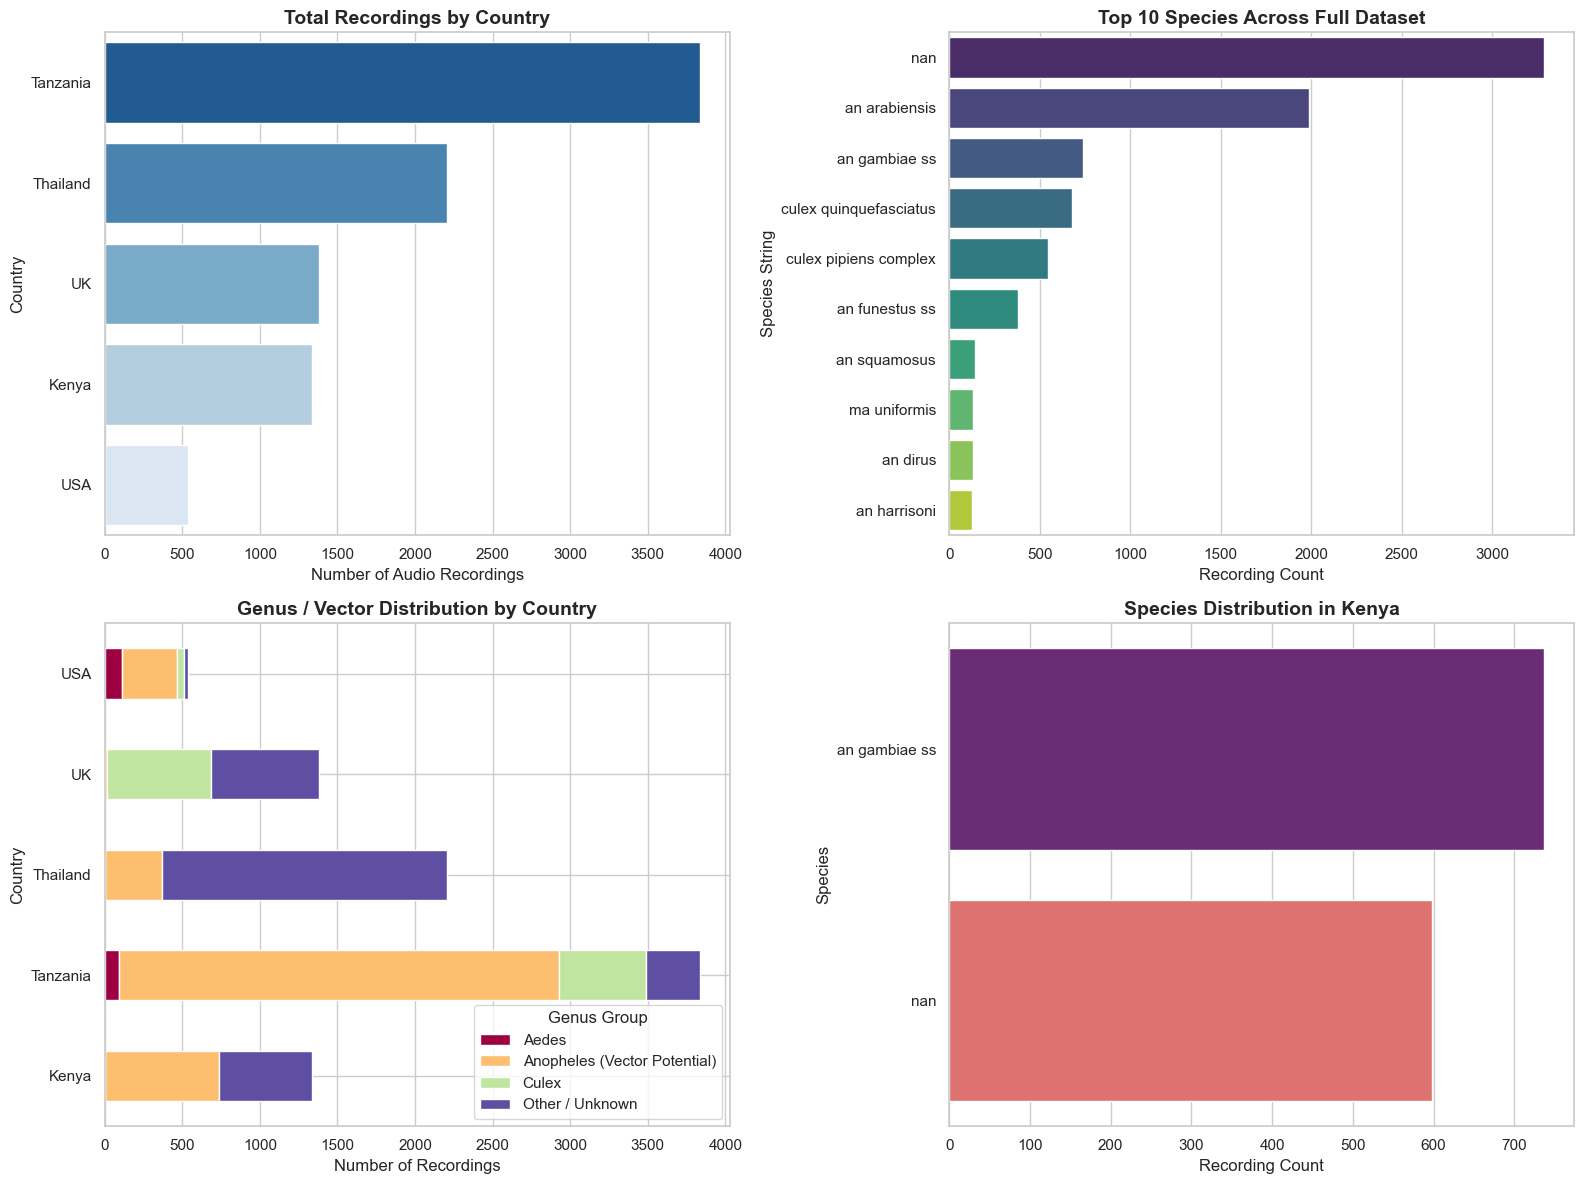

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Geographic Distribution (Recordings per Country)
country_counts = df['clean_country'].value_counts().head(10)
sns.barplot(
    x=country_counts.values, 
    y=country_counts.index, 
    ax=axes[0, 0], 
    palette="Blues_r"
)
axes[0, 0].set_title("Total Recordings by Country", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Number of Audio Recordings")
axes[0, 0].set_ylabel("Country")

# 2. Top 10 Most Common Species in the Entire Dataset
top_species = df['clean_species'].value_counts().head(10)
sns.barplot(
    x=top_species.values, 
    y=top_species.index, 
    ax=axes[0, 1], 
    palette="viridis"
)
axes[0, 1].set_title("Top 10 Species Across Full Dataset", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Recording Count")
axes[0, 1].set_ylabel("Species String")

# 3. Country vs Genus Breakdown (Anopheles vs Culex vs Aedes vs Others)
def extract_genus(species_str):
    s = str(species_str).lower()
    if s.startswith('an') or 'anopheles' in s:
        return 'Anopheles (Vector Potential)'
    elif s.startswith('culex') or s.startswith('cx'):
        return 'Culex'
    elif s.startswith('ae') or 'aedes' in s:
        return 'Aedes'
    else:
        return 'Other / Unknown'

df['genus_group'] = df['clean_species'].apply(extract_genus)
genus_country = pd.crosstab(df['clean_country'], df['genus_group'])

genus_country.plot(
    kind='barh', 
    stacked=True, 
    ax=axes[1, 0], 
    colormap="Spectral"
)
axes[1, 0].set_title("Genus / Vector Distribution by Country", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Number of Recordings")
axes[1, 0].set_ylabel("Country")
axes[1, 0].legend(title="Genus Group", loc="lower right")

# 4. Species Distribution within Kenya (if present)
if len(df_kenya) > 0:
    kenya_top = df_kenya['clean_species'].value_counts().head(8)
    sns.barplot(
        x=kenya_top.values, 
        y=kenya_top.index, 
        ax=axes[1, 1], 
        palette="magma"
    )
    axes[1, 1].set_title("Species Distribution in Kenya", fontsize=14, fontweight="bold")
    axes[1, 1].set_xlabel("Recording Count")
    axes[1, 1].set_ylabel("Species")
else:
    axes[1, 1].text(0.5, 0.5, "No Kenyan Data Found", ha="center", va="center", fontsize=12)
    axes[1, 1].set_title("Kenyan Species Breakdown", fontsize=14)

plt.tight_layout()
plt.show()

## 1. Load and Filter Metadata
The dataset contains multiple species, such as 'an arabiensis', 'culex pipiens complex', 'ae aegypti', 'an funestus ss', 'an squamosus', 'an coustani', 'ma uniformis', and 'ma africanus'. We will filter for specific *Anopheles* and *Culex* classes and map them to numeric integers for PyTorch.

In [10]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset
from tqdm import tqdm

METADATA_PATH = "./neurips_2021_zenodo_0_0_1.csv"
df = pd.read_csv(METADATA_PATH)

# Clean string formatting
df['species'] = df['species'].astype(str).str.strip().str.lower()
df['country'] = df['country'].astype(str).str.strip()

# 1. THE KENYA DEMO DATASET (1,335 files)
df_kenya = df[df['country'].str.contains('Kenya', case=False, na=False)].copy()

# Map Kenya Labels: 'an gambiae ss' -> 1 (Vector), 'nan' -> 0 (Safe/Noise)
df_kenya['label'] = df_kenya['species'].apply(lambda x: 1 if 'an gambiae' in x else 0)

# 2. THE WORKING DATASET (Tanzania, Thailand, UK, USA)
target_working_species = [
    'culex pipiens complex', 'culex quinquefasciatus', 'ae aegypti', 
    'an arabiensis', 'an funestus ss', 'an squamosus', 'an coustani'
]

# Exclude Kenya from the working dataset to prevent data leakage
df_working = df[df['species'].isin(target_working_species) & ~df['country'].str.contains('Kenya', case=False, na=False)].copy()

# Map Working Labels: Culex/Aedes -> 0, Anopheles -> 1
def map_working_labels(species_str):
    if 'culex' in species_str or 'ae aegypti' in species_str:
        return 0
    return 1

df_working['label'] = df_working['species'].apply(map_working_labels)

print(f"➔ Working Dataset: {len(df_working)} files")
print(f"➔ Kenya Demo Dataset: {len(df_kenya)} files ({len(df_kenya[df_kenya['label']==1])} Vectors | {len(df_kenya[df_kenya['label']==0])} Non-Vectors/Noise)")



➔ Working Dataset: 3945 files
➔ Kenya Demo Dataset: 1335 files (737 Vectors | 598 Non-Vectors/Noise)


## 2. Define Audio Processing Logic
We load the `.wav` file, ensure the sample rate is 8000Hz, and pad or truncate the 1D array to exactly `TARGET_LENGTH` samples to guarantee uniform tensor dimensions.

In [12]:
def process_raw_audio(file_id, data_dir=DATA_DIR, sr=SAMPLE_RATE, target_length=TARGET_LENGTH):
    file_path = os.path.join(data_dir, f"{file_id}.wav")
    
    if not os.path.exists(file_path):
        return None
        
    try:
        y, _ = librosa.load(file_path, sr=sr)
        
        # --- NEW: Energy-Based Windowing ---
        if len(y) > target_length:
            # 1. Calculate the squared energy of the signal
            energy = np.power(y, 2)
            # 2. Create a rolling window sum to find the densest 1-second of sound
            window = np.ones(target_length)
            rolling_energy = np.convolve(energy, window, mode='valid')
            # 3. Find the exact starting index of the loudest 1-second chunk
            start_idx = np.argmax(rolling_energy)
            # 4. Slice the audio at that exact hotspot
            y = y[start_idx : start_idx + target_length]
        elif len(y) < target_length:
            # Pad short audio as normal
            y = np.pad(y, (0, target_length - len(y)))
        # -----------------------------------
        
        # Peak Normalization (applied AFTER finding the hotspot)
        max_amplitude = np.max(np.abs(y))
        if max_amplitude > 0:
            y = y / max_amplitude
            
        y = np.reshape(y, (1, target_length))
        return y
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

## 3. Extract Features and Generate TensorDataset
Iterate over the filtered metadata, apply the processing function, and compile the final PyTorch dataset. This step will take some time depending on your disk read speed.

In [13]:
# 3. EXTRACTION FUNCTION
def build_tensor_dataset(dataframe, desc):
    tensors_list = []
    labels_list = []
    
    print(f"\nProcessing {desc} audio files...")
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        file_id = row['id']
        label = row['label']
        
        processed_audio = process_raw_audio(file_id) # Ensure this function is defined above
        
        if processed_audio is not None:
            tensors_list.append(processed_audio)
            labels_list.append(label)
            
    X_tensor = torch.tensor(np.array(tensors_list), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(labels_list), dtype=torch.long)
    return TensorDataset(X_tensor, y_tensor)

# 4. EXPORT TO DISK
WORKING_DATA_PATH = "./processed_working_dataset.pt"
working_dataset = build_tensor_dataset(df_working, "Working Dataset")
torch.save(working_dataset, WORKING_DATA_PATH)

DEMO_DATA_PATH = "./humbugdb_demo_kenya.pt"
kenya_dataset = build_tensor_dataset(df_kenya, "Kenya Demo Dataset")
torch.save(kenya_dataset, DEMO_DATA_PATH)

print("\nData processing complete! Both datasets are saved and isolated.")


Processing Working Dataset audio files...


  0%|          | 0/3945 [00:00<?, ?it/s]/Users/elvisbakunzi/anaconda3/envs/machinelearning/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 3945/3945 [20:23<00:00,  3.22it/s]   



Processing Kenya Demo Dataset audio files...


100%|██████████| 1335/1335 [13:26<00:00,  1.65it/s] 


Data processing complete! Both datasets are saved and isolated.
